In [79]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v3_small

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import slic
from sklearn.linear_model import Ridge

In [80]:
# Định nghĩa lớp giải thích cho mô hình hộp đen sử dụng LIME: G(x)
class LIMEImageExplainer:
    def __init__(self, model: nn.Module, device: str ='cpu'):
        self.model = model # Truyền mô hình đã huấn luyện trước đó vào đây
        self.device = device
        self.transform = transforms.Compose([
            transforms.CenterCrop((480, 480)),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    
    # Phương thức load ảnh
    def load_image(self, image_path: str):
        image = Image.open(fp=image_path).convert('RGB')
        return image

    # Phương thức chuyển đổi biểu diễn ma trận số sang biểu diễn vector có thể hiểu được
    def get_superpixels(self, image: Image, n_segments: int):
        image_array = np.array(image)
        segments = slic(image_array, # Ảnh cần phân mảnh
                        n_segments=n_segments, # Số lượng mảnh cần phân
                        compactness=10, 
                        sigma=1, 
                        start_label=0
                        )
        return segments # Mảng chỉ số segment cho mỗi pixel
    
    # Phương thức lấy mẫu và tạo dữ liệu biến đổi
    def create_perturbed_samples(self, image:Image, segments: np.array, num_samples: int):
        image_array = np.array(image)
        num_superpixels = np.max(segments) + 1
        
        # Tạo ma trận nhị phân ngẫu nhiên với 1 = giữ và 0 = xóa
        binary_features = np.random.randint(0, 2, size=(num_samples, num_superpixels))
        
        pertubed_images = []
        
        for binary_mask in binary_features:
            # Tạo ảnh mới bằng cách giữ hoặc xóa superpixels
            temp_image = image_array.copy()
            
            for supepixel_idx in range(num_superpixels):
                if binary_mask[supepixel_idx] == 0:
                    # Xóa superpixel bằng cách điền màu đen
                    temp_image[segments == supepixel_idx] = [0, 0, 0]
                
            pertubed_images.append(Image.fromarray(temp_image.astype('uint8')))
        
        # perturbed_images: Danh sách các ảnh đã biến đổi
        # binary_features: Ma trận nhị phân biểu diễn sự có mặt của superpixels
        
        return pertubed_images, binary_features
    
    # Phương thức dự đoán cho một batch ảnh
    def predict_batch(self, images: Image):
        batch_tensors = torch.stack([self.transform(img) for img in images])
        batch_tensors = batch_tensors.to(self.device)
        
        with torch.no_grad():
            outputs = self.model(batch_tensors)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
        
        return probabilities.cpu().numpy()

    # Phương thức tính khoảng cách và trọng số
    def compute_distances(self, original_features, perturbed_features):
        # Tính khoảng cách Cosine
        distances = np.sum((original_features - perturbed_features) ** 2, axis=1)
        
        # Chuyển đổi khoảng cách thành trọng số bằng exponential kernel
        kernel_width = 0.25 * np.sqrt(perturbed_features.shape[1])
        weights = np.exp(-distances / (kernel_width ** 2))
        
        return weights
    
    # Phương thức giải thích dự đoán cho một ảnh
    def explain_instance(self, image_path: str, target_class: int, n_segments: int, num_samples: int, num_features: int):
        # Load và xử lý ảnh
        original_image = self.load_image(image_path=image_path)
        
        # Dự đoán lớp cho ảnh gốc
        original_pred = self.predict_batch([original_image])[0]
        
        if target_class is None:
            target_class = np.argmax(original_pred)
            
        print(f"# Đang giải thích lớp {target_class} với xác suất {original_pred[target_class]:.4f}")
        
        # Bước 1: Tạo superpixels
        segments = self.get_superpixels(image=original_image, n_segments=n_segments)
        num_superpixels = np.max(segments) + 1
        print(f'# Phân mảnh ảnh gốc thành {num_superpixels} đoạn.')
        
        # Bước 2: Tạo các mẫu biến đổi
        pertubed_images, binary_features = self.create_perturbed_samples(
            image=original_image,
            segments=segments,
            num_samples=num_samples
        )
        print(f'# Đã tạo ra {len(pertubed_images)} mẫu biến đổi')
        
        # Dự đoán cho các mẫu biến đổi
        print(f"# Đang dự đoán cho {num_samples} mẫu biến đổi...")
        predictions = self.predict_batch(pertubed_images)
        target_predictions = predictions[:, target_class]
        
        # Bước 3: Tính toán trọng số dựa trên độ tương đồng
        print(f'# Đang tính toán trọng số và độ tương đồng...')
        original_features = np.ones(num_superpixels)
        weights = self.compute_distances(original_features, binary_features)
        
        # Bước 4: Huấn luyện mô hình giải thích cục bộ
        print(f"# Đang huấn luyện mô hình giải thích cục bộ...")
        ridge_model = Ridge(alpha=1.0)
        ridge_model.fit(binary_features, target_predictions, sample_weight=weights)
        
        # Bước 5: Lấy các superpixesl quan trọng nhất
        print(f"# Đang lấy {num_features} mẫu quan trọng nhất...")
        coefficients = ridge_model.coef_
        top_features = np.argsort(np.abs(coefficients))[-num_features:][::-1]
        
        
        explanation = {
            'original_image': original_image,
            'segments': segments,
            'coefficients': coefficients,
            'top_features': top_features,
            'target_class': target_class,
            'prediction_prob': original_pred[target_class],
            'model': ridge_model
        }
        
        print(f'==>Trả về kết quả giả thích')
        return explanation
    
    # Phương thức trực quan hóa giải thích
    def visualize_explanation(self, explanation, positive_only=True):
        original_image = explanation['original_image']
        segments = explanation['segments']
        coefficients = explanation['coefficients']
        top_features = explanation['top_features']
        
        # Tạo mask cho các superpixels quan trọng
        mask = np.zeros(segments.shape, dtype=bool)
        
        for idx in top_features:
            if positive_only and coefficients[idx] > 0:
                mask[segments == idx] = True
            elif not positive_only:
                mask[segments == idx] = True
        
        # Tạo hình ảnh giải thích
        image_array = np.array(original_image)
        explanation_image = image_array.copy()
        explanation_image[~mask] = [0, 0, 0]  # Làm đen các vùng không quan trọng
        
        # Vẽ kết quả
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Ảnh gốc
        axes[0].imshow(original_image)
        axes[0].set_title('Ảnh gốc')
        axes[0].axis('off')
        
        # Superpixels
        axes[1].imshow(segments, cmap='nipy_spectral')
        axes[1].set_title(f'Superpixels (tổng: {np.max(segments)+1})')
        axes[1].axis('off')
        
        # Giải thích
        axes[2].imshow(explanation_image)
        axes[2].set_title(f'Giải thích - Lớp {explanation["target_class"]}\n'
                         f'Xác suất: {explanation["prediction_prob"]:.4f}')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [81]:
# Định nghĩa mô hình hộp đen: F(x)
class TrashDetector:
    def __init__(self, checkpoint_path="checkpoints/best_model_finetune.pth"):
        self.device = torch.device("cpu")
        self.labels = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
        self.model = self.load_model(checkpoint_path, len(self.labels))
        
    def load_model(self, path: str, num_classes: int):
        print(f"# [Vision] Loading model from {path}...")
        model = mobilenet_v3_small(weights=None)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
        try:
            model.load_state_dict(torch.load(path, map_location=self.device))
        except FileNotFoundError:
            print(f"# [Vision] ERROR: Checkpoint not found at {path}")
            exit()
        except RuntimeError as e:
            print(f"# [Vision] ERROR: Model mismatch! {e}")
            exit()
            
        model.to(self.device)
        model.eval()
        
        return model

In [82]:
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TrashDetector(checkpoint_path="checkpoints/best_model_finetune.pth").model
    
    # Khởi tạo LIME explainer
    explainer = LIMEImageExplainer(model, device=device)
    
    # URL ảnh mẫu (có thể thay bằng đường dẫn local)
    image_url = "images/capture_640x480_20251210_150005.jpg"
    
    print("\n" + "="*50)
    print("BẮT ĐẦU GIẢI THÍCH DỰ ĐOÁN VỚI LIME")
    print("="*50 + "\n")
    
    # Giải thích dự đoán
    explanation = explainer.explain_instance(
        image_path=image_url,
        target_class=None,  # Tự động chọn lớp được dự đoán
        n_segments=16,      # Số lượng phân đoạn ảnh
        num_samples=500,    # Số lượng mẫu biến đổi
        num_features=1     # Số superpixels quan trọng nhất
    )
    
    # Trực quan hóa kết quả
    print("\nĐang trực quan hóa kết quả...")
    explainer.visualize_explanation(explanation, positive_only=True)
    
    print("\n" + "="*50)
    print("HOÀN THÀNH!")
    print("="*50)

# [Vision] Loading model from checkpoints/best_model_finetune.pth...

BẮT ĐẦU GIẢI THÍCH DỰ ĐOÁN VỚI LIME

# Đang giải thích lớp 1 với xác suất 0.9919
# Phân mảnh ảnh gốc thành 10 đoạn.
# Đã tạo ra 500 mẫu biến đổi
# Đang dự đoán cho 500 mẫu biến đổi...
# Đang tính toán trọng số và độ tương đồng...
# Đang huấn luyện mô hình giải thích cục bộ...
# Đang lấy 1 mẫu quan trọng nhất...
==>Trả về kết quả giả thích

Đang trực quan hóa kết quả...


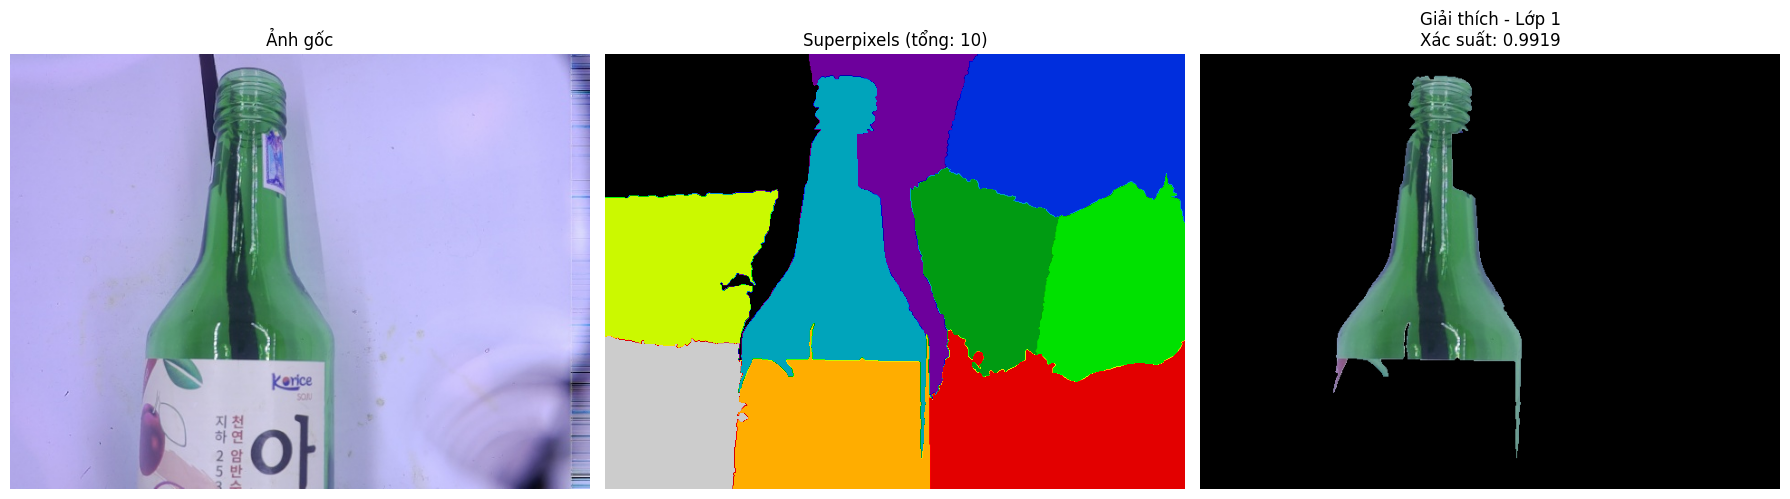


HOÀN THÀNH!


In [83]:
if __name__ == "__main__":
    main()